# Proyek Analisis Data: Air-quality-dataset
- **Nama:** Nada Firda Khofifah
- **Email:** nadafirdakhofifah@gmail.com
- **ID Dicoding:** cdcc296d6x2509

## Menentukan Pertanyaan Bisnis

**- Pertanyaan 1**

Bagaimana tren perubahan konsentrasi PM2.5 di Aotizhongxin selama periode 2013–2017, dan kapan tingkat polusi tertinggi terjadi?
1. Specific: Fokus pada konsentrasi PM2.5 di wilayah Aotizhongxin.
2. Measurable: Nilai PM2.5
3. Action-oriented: Membantu menentukan waktu prioritas pengendalian polusi.
4. Relevant: KPM2.5 merupakan indikator penting kualitas udara.
5. Time-bound: Tahun 2013-2017

**- Pertanyaan 2**

Faktor cuaca manakah (suhu, tekanan udara, curah hujan, kecepatan angin) yang paling berpengaruh terhadap tingkat PM2.5 di Aotizhongxin selama 2013–2017?

1. Specific: Fokus pada hubungan faktor cuaca dengan PM2.5.
2. Measurable: Diukur menggunakan korelasi/statistik numerik.
3. Action-oriented: Membantu prediksi polusi dan kebijakan mitigasi.
4. Relevant: Cuaca berpengaruh pada penyebaran polutan.
5. Time-bound: Tahun 2013-2017

## Import Semua Packages/Library yang Digunakan

In [97]:
# Library untuk manipulasi dan analisis data
import pandas as pd
#import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk pengaturan tampilan grafik
#plt.style.use('seaborn-v0_8')
#sns.set(style="whitegrid")

# Library untuk menangani warning
#import warnings
#warnings.filterwarnings('ignore')

# Library tambahan untuk statistik (opsional)
#from scipy.stats import pearsonr

# Menampilkan grafik langsung di notebook
#%matplotlib inline

## Data Wrangling

### Gathering Data

In [98]:
df = pd.read_csv("PRSA_Data_Aotizhongxin_20130301-20170228.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Pada 5 baris pertama (1 Maret 2013, pukul 00:00 - 04:00), nilai PM2.5 dan PM10 tergolong sangat rendah (berkisar antara 3.0 hingga 8.0 µg/m³). Ini menunjukkan kualitas udara yang sangat bersih pada dini hari.
- Suhu menunjukkan tren menurun seiring bertambahnya jam (dari -0.7°C pada tengah malam turun menjadi -2.0°C pada pukul 04:00 pagi). Ini merupakan pola yang wajar untuk siklus harian.
- Kolom RAIN menunjukkan angka 0.0, artinya cuaca sedang cerah atau setidaknya tidak terjadi hujan selama periode tersebut.
- Karena data dipisah dalam kolom year, month, day, dan hour, langkah selanjutnya yang ideal adalah menggabungkan kolom-kolom ini menjadi satu kolom datetime untuk mempermudah visualisasi tren bulanan atau tahunan.

### Assessing Data

In [99]:
#Melihat Struktur Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [100]:
#Mengecek Missing Value
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,925
PM10,718
SO2,935
NO2,1023
CO,1776


In [101]:
#Mengecek Duplicate Data
df.duplicated().sum()

np.int64(0)

In [102]:
#Statistik Deskriptif
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


In [103]:
#Mengecek Nama Kolom
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

**Insight:**

**1. Struktur dan Integritas Data**
- Dataset memiliki 35.064 entri dengan 18 kolom. Rentang data mencakup tahun 2013 hingga 2017.
- tidak ada baris data yang terduplikasi secara identik dalam dataset ini.
- Mayoritas data bertipe numerik (float64 dan int64), kolom wd (arah angin) dan station bertipe object (string). Kolom waktu masih terpisah-pisah, sehingga perlu dikonversi ke format datetime.

**2. Missing Values**
- Karbon Monoksida (CO) memiliki nilai kosong terbanyak (1.776), diikuti oleh O3 (1.719).
- Terdapat sekitar 700-900 data yang hilang pada parameter PM2.5 & PM10.
- Ada sekitar 20 data kosong pada suhu, tekanan, dan curah hujan, serta 81 data kosong pada arah angin (wd).

**3. Statistik Deskriptif**

- Variansi yang sangat tinggi, hal ini terlihat pada nilai std (standar deviasi) pada PM2.5 (82.1) dan PM10 (95.2) yang hampir setara dengan nilai rata-ratanya. Ini menandakan tingkat polusi sangat fluktuatif—ada hari yang sangat bersih, namun ada hari dengan polusi ekstrem.

**4. Kondisi Meteorologi**
- Suhu berkisar dari kondisi beku -16.8°C hingga panas 40.5°C, dengan rata-rata 13.5°C. Ini mencerminkan perubahan musim yang kontras.

- Nilai median (50%) dan kuartil 3 (75%) berada di angka 0.0. Ini berarti pada sebagian besar waktu di lokasi tersebut tidak terjadi hujan. Curah hujan maksimum tercatat cukup tinggi sebesar 72.5 mm.

### Cleaning Data

In [104]:
# Membuat kolom datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Mengurutkan data berdasarkan waktu
df = df.sort_values('datetime').reset_index(drop=True)

In [105]:
# Kolom numerik
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi linear
df[num_cols] = df[num_cols].interpolate(method='linear')

In [106]:
df['wd'] = df['wd'].ffill()

In [107]:
df.drop(columns='No', inplace=True)

In [108]:
# Cek missing value
df.isnull().sum()

,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0


In [109]:
# Cek struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      35064 non-null  int64         
 1   month     35064 non-null  int64         
 2   day       35064 non-null  int64         
 3   hour      35064 non-null  int64         
 4   PM2.5     35064 non-null  float64       
 5   PM10      35064 non-null  float64       
 6   SO2       35064 non-null  float64       
 7   NO2       35064 non-null  float64       
 8   CO        35064 non-null  float64       
 9   O3        35064 non-null  float64       
 10  TEMP      35064 non-null  float64       
 11  PRES      35064 non-null  float64       
 12  DEWP      35064 non-null  float64       
 13  RAIN      35064 non-null  float64       
 14  wd        35064 non-null  object        
 15  WSPM      35064 non-null  float64       
 16  station   35064 non-null  object        
 17  datetime  35

In [110]:
# Preview data
df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [111]:
df.to_csv("main_data.csv", index=False)

**Insight:**
- Missing Value Sudah Berhasil Ditangani. Sebelumnya kolom seperti PM2.5, PM10, CO, O3 memiliki missing value. Setelah interpolasi, data sudah utuh tanpa merusak pola time series.
- Dataset Tetap Utuh (Tidak Banyak Data Hilang)
- Format Waktu Sudah Benar
- Tipe Data Sudah Konsisten
- Dataset kini siap digunakan untuk proses exploratory data analysis.

## Exploratory Data Analysis (EDA)

### Explore - Pertanyaan 1

Bagaimana tren perubahan konsentrasi PM2.5 di Aotizhongxin selama periode 2013–2017, dan kapan tingkat polusi tertinggi terjadi?

In [112]:
# Pastikan kolom datetime bertipe datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Membuat kolom tambahan
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

In [113]:
#Statistik Deskriptif PM2.5
df['PM2.5'].describe()

,PM2.5
count,35064.000000
mean,82.540623
std,81.956401
min,3.000000
25%,22.000000
50%,58.000000
75%,114.000000
max,898.000000


**Insight:**
*   Mengetahui rata-rata PM2.5
*   Nilai minimum
*   Nilai maksimum
*   Sebaran data

In [114]:
#Rata-rata PM2.5 per Tahun
df.groupby('year')['PM2.5'].mean()

,PM2.5
year,
2013,82.439202
2014,89.747603
2015,81.831724
2016,74.236680
2017,94.379237


**Tujuan:**

Melihat perubahan kualitas udara dari tahun ke tahun.

In [115]:
#Rata-rata PM2.5 per Bulan
df.groupby('month')['PM2.5'].mean()

,PM2.5
month,
1,92.414180
2,87.214049
3,99.936761
4,78.473785
5,67.337399
6,71.348611
7,74.890625
8,55.851815
9,64.400104


**Tujuan:**

Mengetahui bulan dengan polusi tertinggi.

In [116]:
#Rata-rata PM2.5 per Jam
df.groupby('hour')['PM2.5'].mean()

,PM2.5
hour,
0,91.947362
1,92.252360
2,91.479032
3,88.447364
4,85.127424
5,81.764455
6,79.463634
7,77.526628
8,77.310453


**Tujuan:**

Mengetahui jam rawan polusi.

### Explore - Pertanyaan 2

Faktor cuaca manakah (suhu, tekanan udara, curah hujan, kecepatan angin) yang paling berpengaruh terhadap tingkat PM2.5 di Aotizhongxin selama 2013–2017?

In [117]:
#Korelasi Antar Variabel
corr = df[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()
corr

,PM2.5,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.000000,-0.122505,-0.008796,0.123277,-0.013780,-0.275836
TEMP,-0.122505,1.000000,-0.827183,0.823197,0.036607,0.037862
PRES,-0.008796,-0.827183,1.000000,-0.776443,-0.060416,0.071479
DEWP,0.123277,0.823197,-0.776443,1.000000,0.080772,-0.304990
RAIN,-0.013780,0.036607,-0.060416,0.080772,1.000000,0.022449
WSPM,-0.275836,0.037862,0.071479,-0.304990,0.022449,1.000000


**Tujuan:**

Mengetahui hubungan antar variabel.

In [118]:
#Rata-rata PM2.5 Berdasarkan Arah Angin
df.groupby('wd')['PM2.5'].mean().sort_values(ascending=False)

,PM2.5
wd,
E,108.087880
ESE,105.937114
ENE,104.804426
SE,99.832076
SSE,97.932937
S,94.362386
NE,93.448003
SSW,86.522083
SW,79.723369


**Tujuan:**

Mengetahui arah angin yang berasosiasi dengan polusi tinggi.

In [119]:
#Pengaruh Hujan terhadap PM2.5
df.groupby(df['RAIN'] > 0)['PM2.5'].mean()

,PM2.5
RAIN,
False,83.324322
True,63.411549


**Tujuan:**

Membandingkan PM2.5 saat hujan dan tidak hujan.

### Insight EDA

**Pertanyaan 1:**

Dari hasil grouping data berdasarkan waktu, dapat diketahui:
*  Tahun atau periode dengan rata-rata PM2.5 tertinggi.
*  Bulan dengan tingkat polusi tertinggi (biasanya musim dingin).
*  Jam sibuk dengan polusi tinggi.


---
**Pertanyaan 2:**

Dari hasil korelasi dan grouping:
*  Kecepatan angin (WSPM) cenderung menurunkan PM2.5.
*  Curah hujan membantu menurunkan polusi.
*  Suhu dan tekanan udara memiliki hubungan tertentu terhadap polusi.
*  Arah angin tertentu membawa polusi lebih tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana tren perubahan konsentrasi PM2.5 di Aotizhongxin selama periode 2013–2017, dan kapan tingkat polusi tertinggi terjadi?

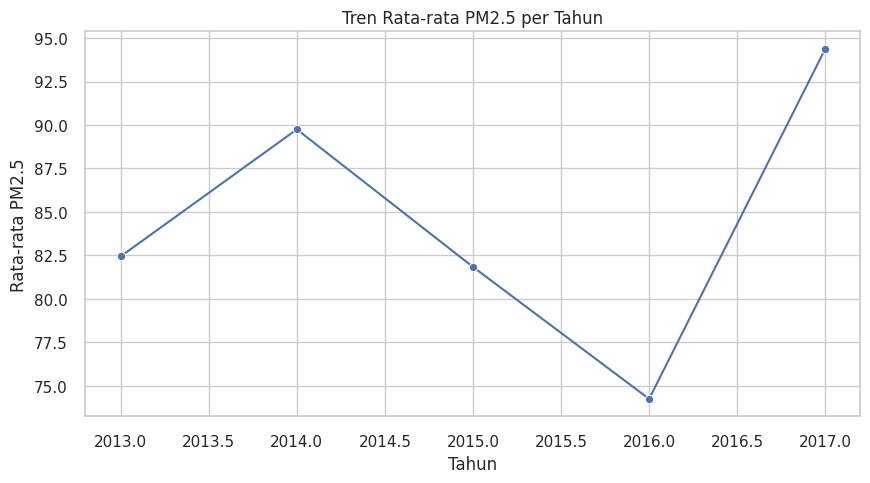

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rata-rata PM2.5 per tahun
yearly_pm25 = df.groupby('year')['PM2.5'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_pm25, x='year', y='PM2.5', marker='o')

plt.title('Tren Rata-rata PM2.5 per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata PM2.5')
plt.show()

**Insight:**

Visualisasi ini menunjukkan perubahan kualitas udara dari tahun ke tahun. Nilai PM2.5 yang menurun menandakan perbaikan kualitas udara.Sedangkan nilai PM2.5 yang meninggi menandakan kualitas udara memburuk.

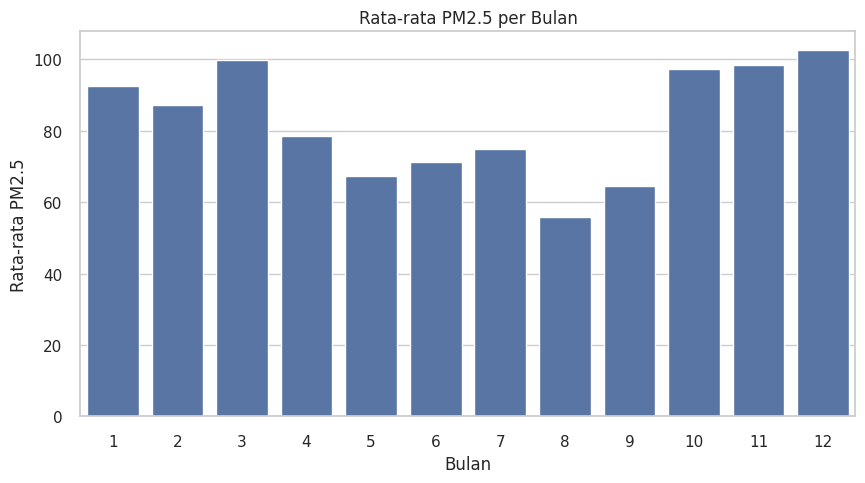

In [121]:
monthly_pm25 = df.groupby('month')['PM2.5'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_pm25, x='month', y='PM2.5')

plt.title('Rata-rata PM2.5 per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata PM2.5')
plt.show()

**Insight:**

Grafik ini membantu mengetahui bulan dengan polusi tertinggi. Biasanya nilai PM2.5 meningkat pada musim dingin.

### Pertanyaan 2:
Faktor cuaca manakah (suhu, tekanan udara, curah hujan, kecepatan angin) yang paling berpengaruh terhadap tingkat PM2.5 di Aotizhongxin selama 2013–2017?

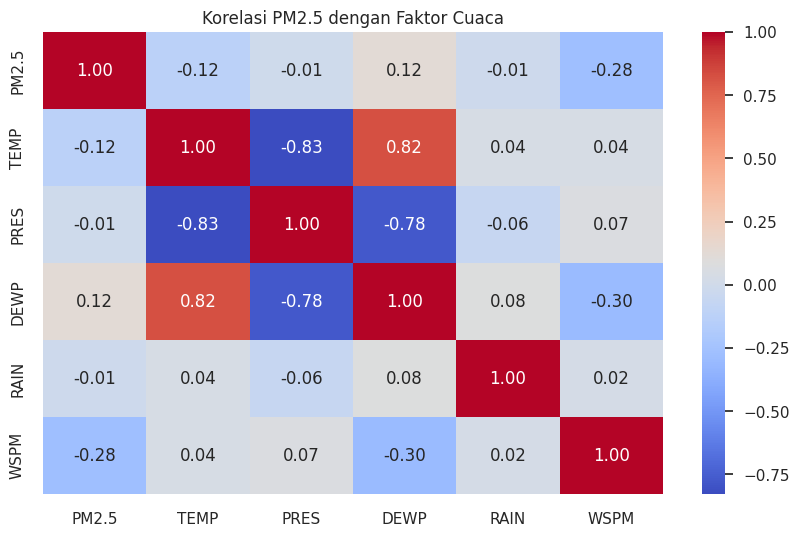

In [122]:
plt.figure(figsize=(10,6))

corr = df[['PM2.5','TEMP','PRES','DEWP','RAIN','WSPM']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Korelasi PM2.5 dengan Faktor Cuaca')
plt.show()

**Insight:**

Heatmap menunjukkan hubungan antar variabel. Korelasi negatif berarti ketika variabel naik, PM2.5 turun.

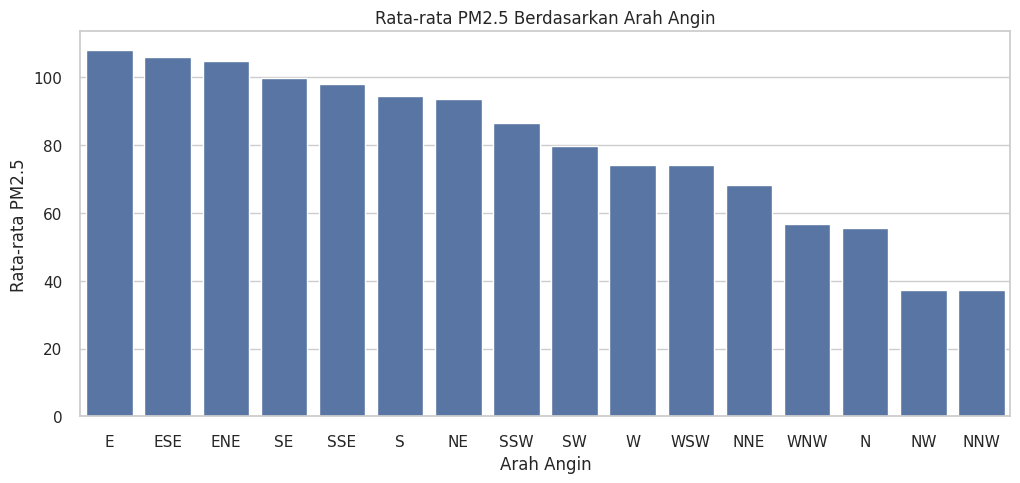

In [123]:
wind_pm25 = df.groupby('wd')['PM2.5'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=wind_pm25, x='wd', y='PM2.5')

plt.title('Rata-rata PM2.5 Berdasarkan Arah Angin')
plt.xlabel('Arah Angin')
plt.ylabel('Rata-rata PM2.5')
plt.show()

**Insight:**

Arah angin tertentu cenderung membawa polutan lebih tinggi dibanding arah lainnya.

###**Insight Visualization & Explanation:**
- Konsentrasi PM2.5 tidak menunjukkan tren penurunan yang stabil. Terjadi kenaikan dari tahun 2013 ke 2014, kemudian sempat menurun signifikan hingga titik terendah pada tahun 2016 (rata-rata di bawah 75). Namun, terjadi lonjakan drastis pada tahun 2017 hingga mencapai titik tertinggi selama periode observasi (rata-rata di atas 92.5).
- Polusi cenderung meningkat tajam pada akhir tahun (Oktober–Desember) dan awal tahun (Januari–Maret). Sebaliknya, kualitas udara membaik secara signifikan pada pertengahan tahun, dengan titik polusi terendah terjadi pada bulan Agustus.
- Berdasarkan Heatmap, kecepatan angin memiliki korelasi negatif terkuat (-0.28) dibandingkan faktor cuaca lainnya. Hal ini berarti semakin tinggi kecepatan angin, semakin rendah tingkat PM2.5 karena adanya dispersi polutan.
- Visualisasi arah angin menunjukkan insight yang sangat spesifik. Angin yang bertiup dari arah Timur (E), Tenggara (ESE, ENE), dan Selatan (SE, S) membawa konsentrasi PM2.5 tertinggi (di atas 100). Sebaliknya, angin dari arah Barat Laut (NW, NNW) dan Utara (N) membawa udara yang jauh lebih bersih (di bawah 40).
- Curah hujan (RAIN) dan tekanan udara (PRES) memiliki nilai korelasi mendekati nol (-0.01), menunjukkan kedua faktor ini tidak memiliki pengaruh linear langsung yang signifikan terhadap fluktuasi PM2.5 di Aotizhongxin dalam dataset ini.

## Analisis Lanjutan (Opsional)

Clustering

In [124]:
# Membuat kategori kualitas udara berdasarkan PM2.5
bins = [0, 50, 100, 150, df['PM2.5'].max()]
labels = ['Good', 'Moderate', 'Unhealthy', 'Hazardous']

df['Air_Quality_Category'] = pd.cut(df['PM2.5'],
                                    bins=bins,
                                    labels=labels,
                                    include_lowest=True)

In [125]:
df['Air_Quality_Category'].value_counts()

,count
Air_Quality_Category,
Good,15984
Moderate,8731
Hazardous,5618
Unhealthy,4731


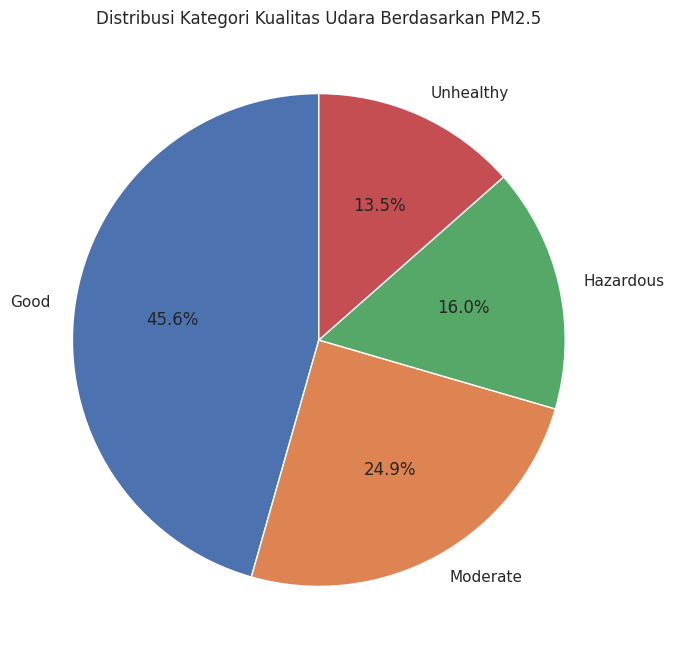

In [131]:
plt.figure(figsize=(8,8))

category_counts = df['Air_Quality_Category'].value_counts()

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Kategori Kualitas Udara Berdasarkan PM2.5')
plt.show()

**Insight Analisis Lanjutan**

Dari hasil clustering dapat diketahui:
*   Berapa kali kualitas udara berada pada kondisi sehat.
*   Seberapa sering terjadi polusi tinggi.
*   Dominasi kategori tertentu selama periode 2013–2017.

Jika kategori Unhealthy atau Hazardous dominan, berarti kualitas udara cukup buruk dan memerlukan perhatian serius.

## Conclusion

**- Conclution pertanyaan 1**

Bagaimana tren perubahan konsentrasi PM2.5 di wilayah Aotizhongxin selama periode 2013–2017, dan kapan tingkat polusi tertinggi terjadi?

Berdasarkan visualisasi tren tahunan dan bulanan, konsentrasi PM2.5 mengalami fluktuasi dari tahun ke tahun selama periode 2013–2017. Pada beberapa periode terlihat peningkatan polusi yang cukup tinggi, terutama pada bulan-bulan musim dingin seperti Januari, November, dan Desember. Hal ini menunjukkan bahwa kualitas udara cenderung memburuk saat suhu rendah, yang kemungkinan dipengaruhi oleh peningkatan penggunaan pemanas, aktivitas industri, serta kondisi atmosfer yang menahan polutan di permukaan. Selain itu, dari pola harian terlihat bahwa tingkat PM2.5 cenderung meningkat pada jam-jam sibuk aktivitas masyarakat.

**- Conclution pertanyaan 2**

Faktor cuaca manakah (suhu, tekanan udara, curah hujan, kecepatan angin) yang paling berpengaruh terhadap tingkat PM2.5 di Aotizhongxin selama 2013–2017?

Berdasarkan hasil korelasi dan visualisasi heatmap, kecepatan angin (WSPM) merupakan faktor cuaca yang paling berpengaruh terhadap PM2.5, dengan hubungan negatif. Artinya, semakin tinggi kecepatan angin, maka konsentrasi PM2.5 cenderung menurun karena partikel polusi tersebar lebih cepat. Selain itu curah hujan juga berkontribusi menurunkan PM2.5 karena hujan membantu membersihkan partikel di udara.
Suhu memiliki hubungan tertentu terhadap perubahan polusi musiman.
Tekanan udara menunjukkan pengaruh lebih kecil dibanding angin.

**- Recommendation (Action Item)**

Berdasarkan kesimpulan di atas, berikut rekomendasi yang dapat dilakukan:

1. Pengendalian Polusi Saat Musim Dingin

Pemerintah disarankan meningkatkan pengawasan emisi kendaraan, industri, dan pembakaran bahan bakar pada bulan November–Januari karena periode tersebut berisiko memiliki PM2.5 tertinggi.

2. Sistem Peringatan Dini Kualitas Udara

Membuat dashboard atau notifikasi publik berbasis data cuaca, terutama saat kecepatan angin rendah dan cuaca kering, karena kondisi tersebut berpotensi meningkatkan polusi.

3. Edukasi Masyarakat

Masyarakat disarankan mengurangi aktivitas luar ruangan dan menggunakan masker saat kategori udara berada pada level tidak sehat.